In [7]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn

data_path = '../../../data/mujoco'
model_path = '../../../models/mujoco'
result_path = '../../../results/mujoco'

### Creating baseline dataset

In [2]:
data_nsample = 918
data = util_data.read_datafile(f'{data_path}/walker2d_baseline_0', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 17
act_ndim = 6
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

read data shape: torch.Size([80, 918, 23])
read observations shape: torch.Size([80, 918, 17])
read actions shape: torch.Size([80, 918, 6])
shape of observations for training: torch.Size([80, 917, 17])
shape of next observations for training: torch.Size([80, 917, 17])
shape of actions for training: torch.Size([80, 917, 6])


In [3]:
model = example_mujoco.global_dynamics(obs_ndim=obs_ndim, act_ndim=act_ndim)

load_pretrained = False
savemodel = False

if load_pretrained:
    # --! load trained weights into the model
    model_path = f'{model_path}/walker2d_global_checkpoint.pth'
    model.load_state_dict(torch.load(model_path, weights_only=True))

else:
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = torch.nn.MSELoss()

    num_epochs = 1_000

    for epoch in range(num_epochs):
        total_loss = 0.0

        for s, a, s_delta in dataloader:
            pred = model(s, a)
            loss = loss_fn(pred, s_delta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"epoch {epoch}, loss: {total_loss / len(dataloader):.6f}")

if savemodel:
    torch.save(model.state_dict(), f'{model_path}/walker2d_global_checkpoint.pth')

epoch 0, loss: 0.083503
epoch 20, loss: 0.037345
epoch 40, loss: 0.025646
epoch 60, loss: 0.019525
epoch 80, loss: 0.015682
epoch 100, loss: 0.013345
epoch 120, loss: 0.011875
epoch 140, loss: 0.010602
epoch 160, loss: 0.009738
epoch 180, loss: 0.009059
epoch 200, loss: 0.008779
epoch 220, loss: 0.008090
epoch 240, loss: 0.008118
epoch 260, loss: 0.007345
epoch 280, loss: 0.007026
epoch 300, loss: 0.007014
epoch 320, loss: 0.006569
epoch 340, loss: 0.006459
epoch 360, loss: 0.006142
epoch 380, loss: 0.005915
epoch 400, loss: 0.005770
epoch 420, loss: 0.005678
epoch 440, loss: 0.005563
epoch 460, loss: 0.005352
epoch 480, loss: 0.005218
epoch 500, loss: 0.005320
epoch 520, loss: 0.005034
epoch 540, loss: 0.005152
epoch 560, loss: 0.004838
epoch 580, loss: 0.004761
epoch 600, loss: 0.004674
epoch 620, loss: 0.004564
epoch 640, loss: 0.004946
epoch 660, loss: 0.004462
epoch 680, loss: 0.004413
epoch 700, loss: 0.004372
epoch 720, loss: 0.004225
epoch 740, loss: 0.004367
epoch 760, loss: 0

In [4]:
model.eval()
util_nn.freeze_module(model)

this_traj = 1

s0 = obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_global(model, s0, act[this_traj])
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 17])


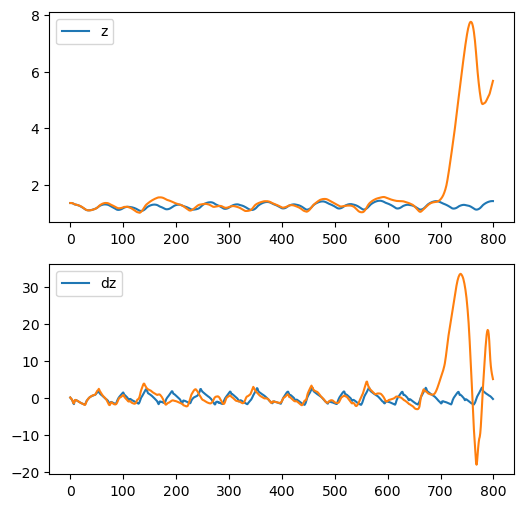

In [5]:
disp_end = 800
datasaved = False

with torch.no_grad():
    plot_rollout_traj = torch.unsqueeze(rollout_traj, 0)
    plot_rollout_traj = torch.cat([
        example_mujoco.denormalize_standard(
            s, mean, std) for s, mean, std in zip(torch.split(plot_rollout_traj, 1, dim=-1), obs_mean, obs_std)], dim=-1)
    plot_obs = torch.cat([
        example_mujoco.denormalize_standard(
            s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

    plt.figure(figsize=(6,6))

    plt.subplot(2,1,1)
    plt.plot(plot_obs[this_traj, :disp_end, 0], label='z')
    plt.plot(plot_rollout_traj[0, :disp_end, 0])
    plt.legend()

    plt.subplot(2,1,2)
    plt.plot(plot_obs[this_traj, :disp_end, 9], label='dz')
    plt.plot(plot_rollout_traj[0, :disp_end, 9])
    plt.legend()

    plt.show()

    if datasaved:
        save_step = torch.arange(obs.shape[1]).reshape(1, -1, 1)
        savedata = np.concatenate([
            save_step[:1, :disp_end, :1],
            plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [9]],
            plot_rollout_traj[:1, :disp_end, :1], plot_rollout_traj[:1, :disp_end, [9]]], axis=2)
        util_data.write_datafile(f'{result_path}/walker2d_global_rollout', savedata, delim=' ')

In [8]:
traj_mse = []
with torch.no_grad():
    for j in range(obs.shape[0]): # trajectory
        mse = []
        for h in range(1, obs.shape[1]): # horizon
            s0 = obs[j, 0]
            cmp_rollout = example_mujoco.rollout_global(model, s0, act[j, :h])

            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)
            mse.append(F.mse_loss(cmp_rollout, cmp_obs))
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)

tensor(0.0922)
tensor(0.1099)


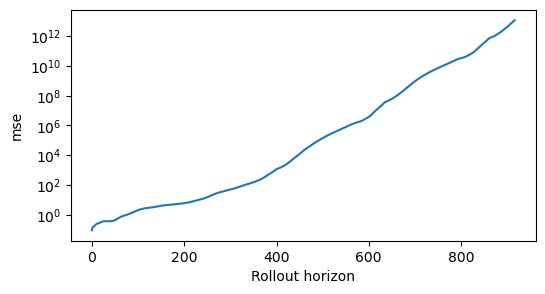

In [10]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.xlabel('Rollout horizon')
    plt.ylabel('mse')
    plt.show()

datasaved = False
if datasaved:
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_global_mse', savedata, delim=' ')